In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load


# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os

for dirname, _, filenames in os.walk("./"):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# 1. Frame the problem
Using the customer description, Define the problem your trying to solve in your own words (remember this is not technial but must be specific so the customer understands the project

In [ ]:
"""Identify housing data (with at least 1000 distinct examples) that cannot come from
a preprocessed dataset. It must include at MINIMUM these following attributes: price, age, 
number of bed rooms, number of bathrooms, and square feet of the house. These features must go
through a model that uses the data to predict the selling price of properties in your selected
city in the United States. The project must be coded in Python and utilize Scikit-learn; all uopdates
must be pushed to Git, as that is where the majority of t."""

# 2. Get the Data 
Define how you recieved the data (provided, gathered..)

In [118]:
from homeharvest import scrape_property
import pandas as pd

# Scrape 7000 datasets from Chicago sold within the past year using
# the homeharvest library. Accept extra property data to gain as many features as possible for
# a more accurate evaluation. The data is raw and original.
properties_df: pd.DataFrame = scrape_property(
    location="Chicago, IL",
    listing_type="sold",
    past_days=730,
    limit=10000,
    extra_property_data=True
)

properties_df.to_csv("listing.csv", index=False)


# 3. Explore the Data
Gain insights into the data you have from step 2, making sure to identify any bias

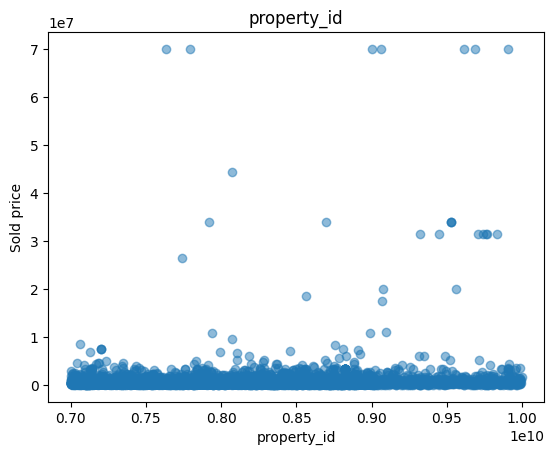

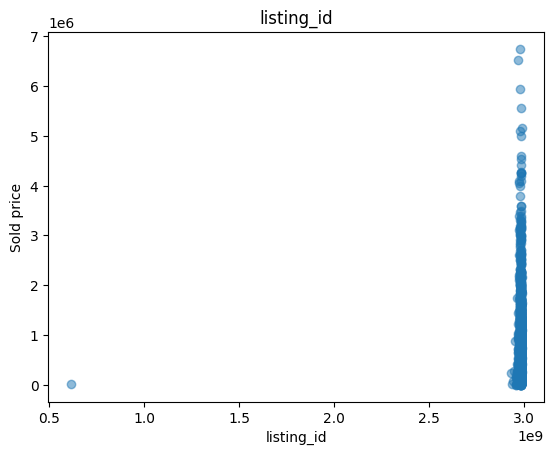

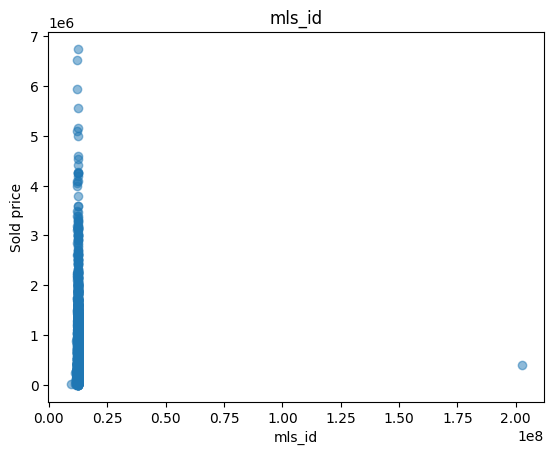

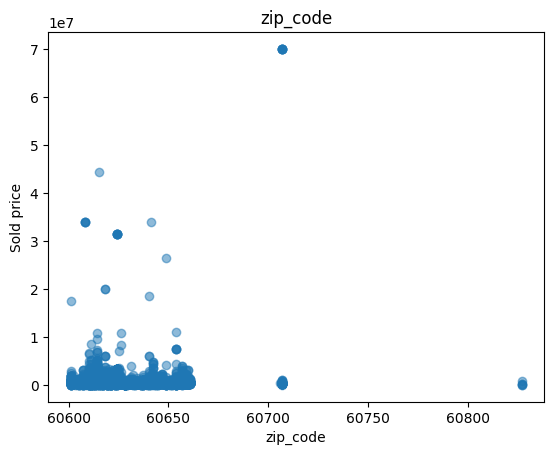

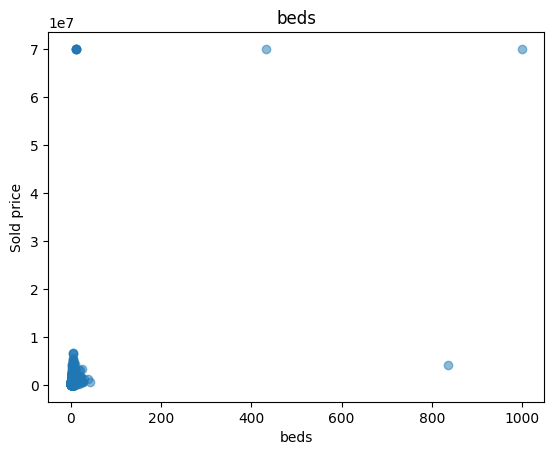

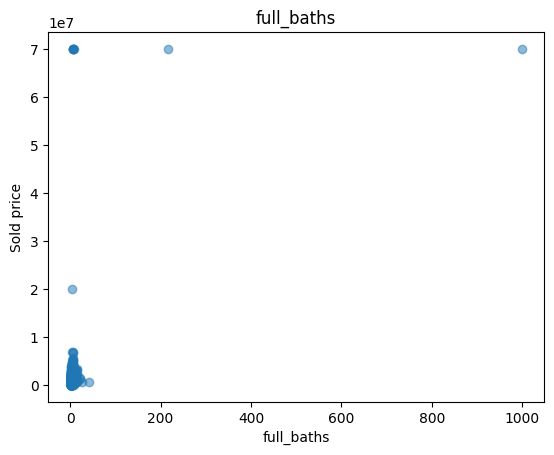

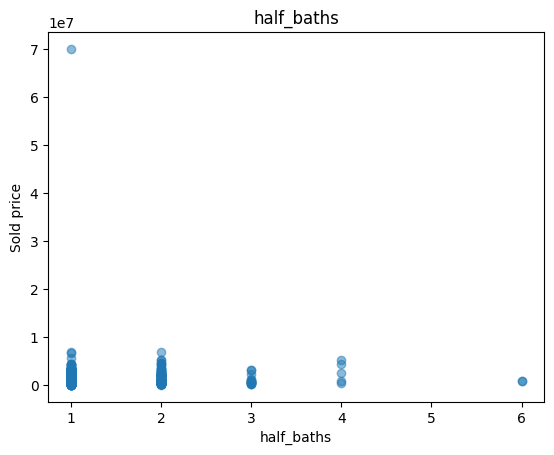

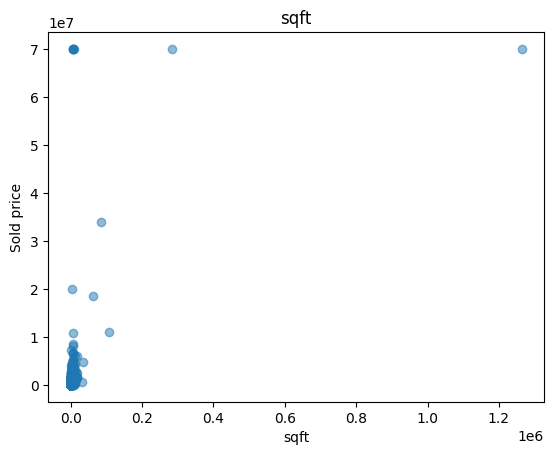

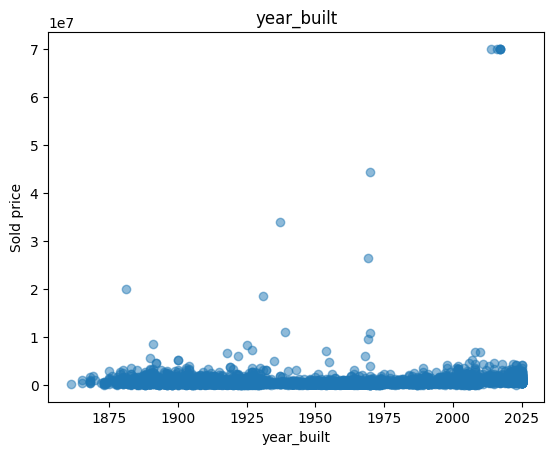

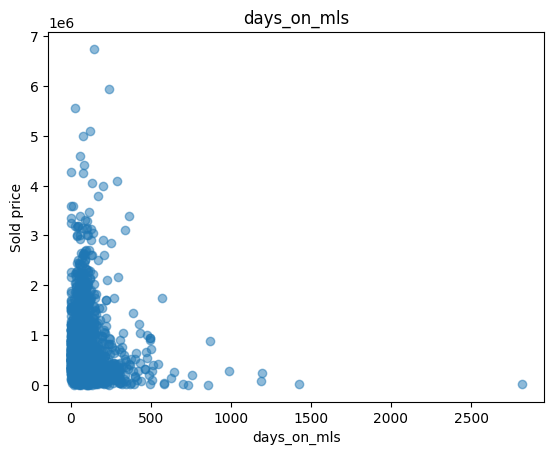

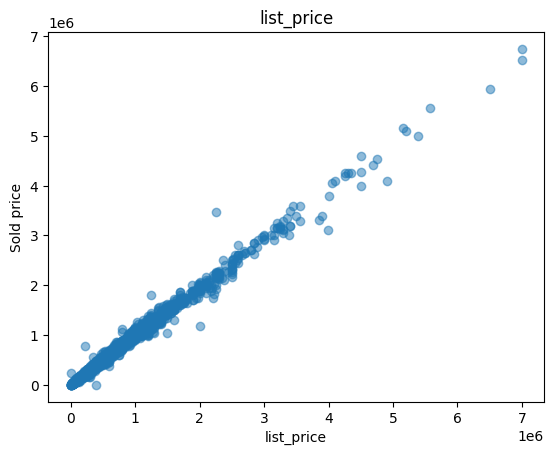

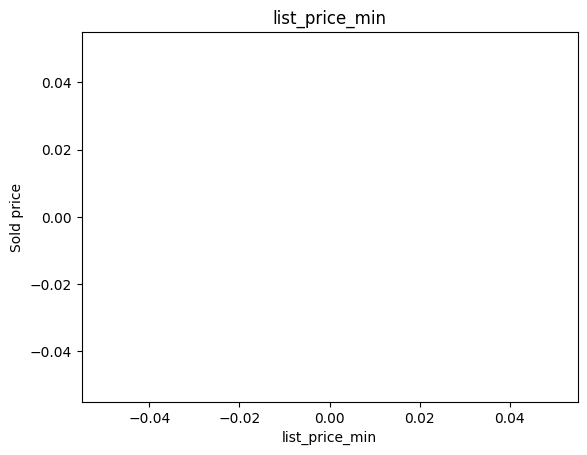

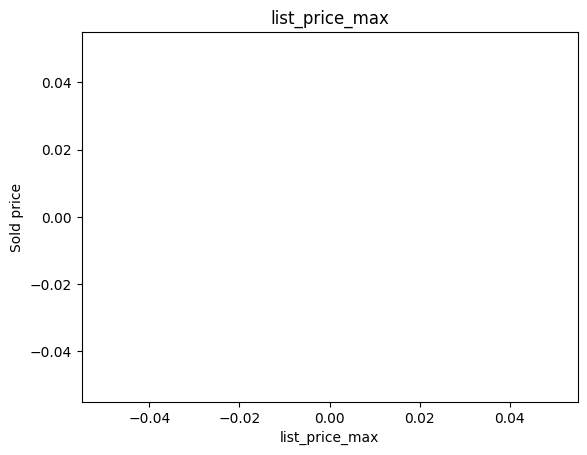

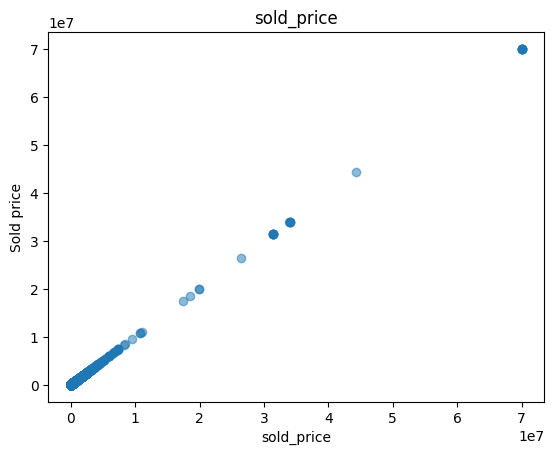

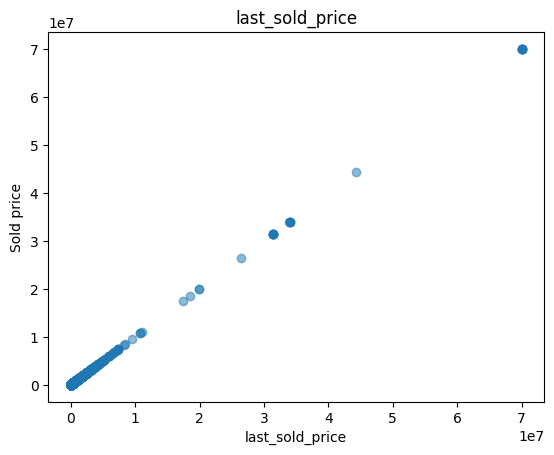

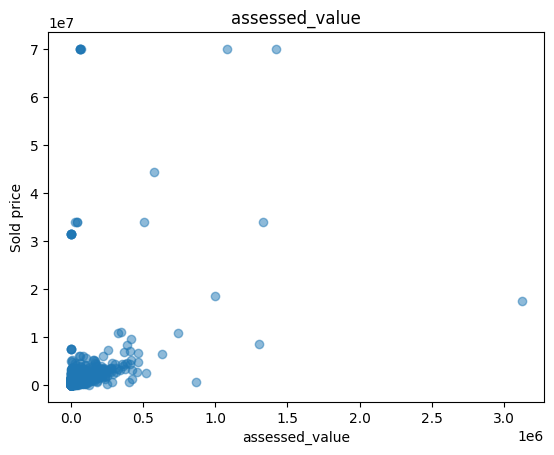

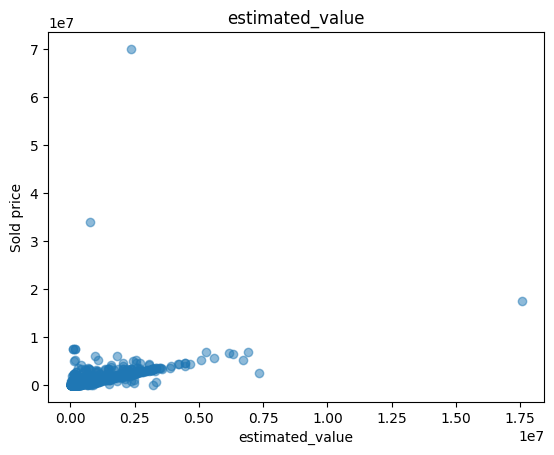

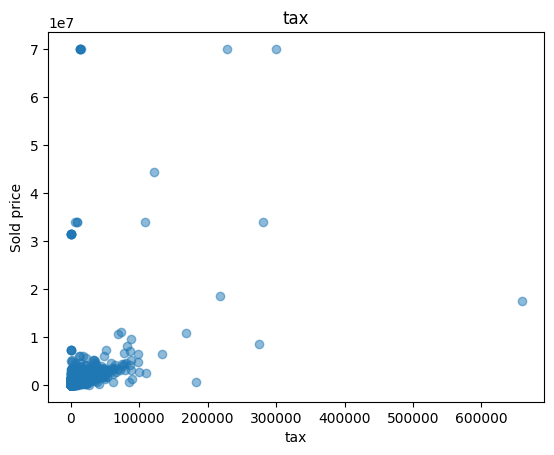

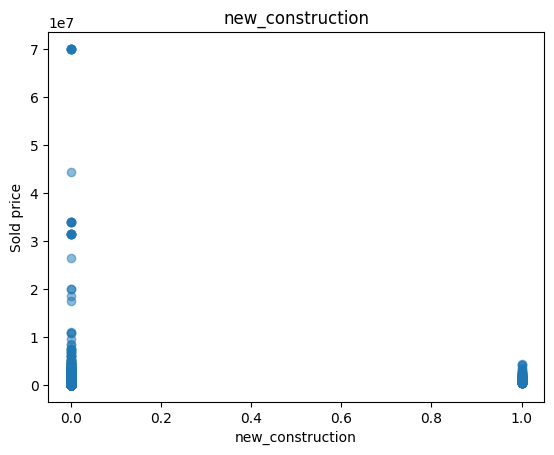

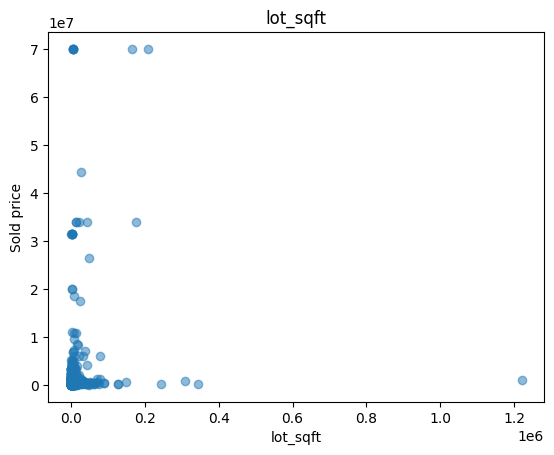

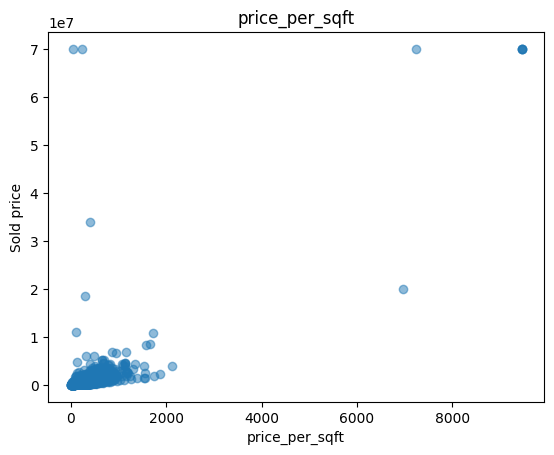

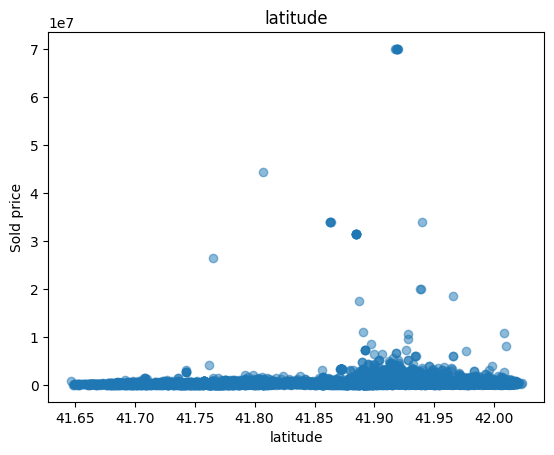

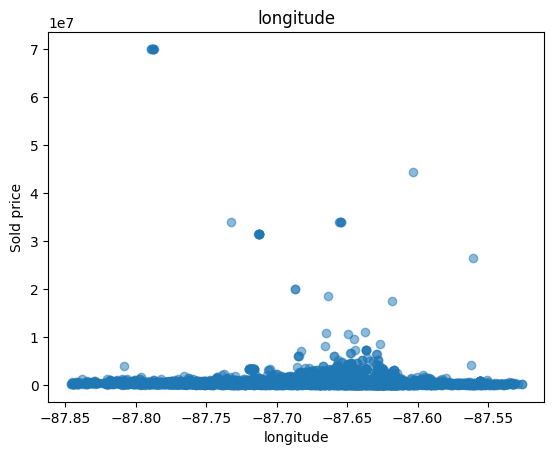

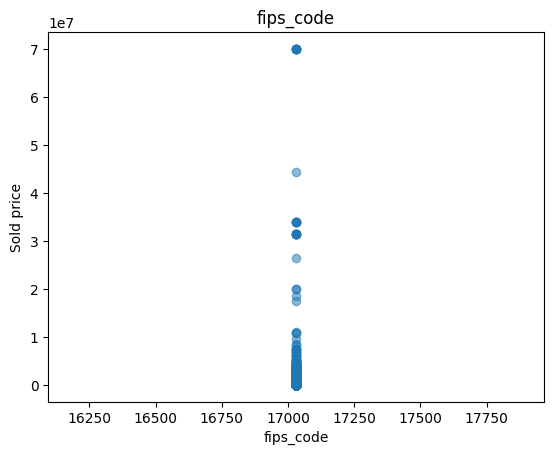

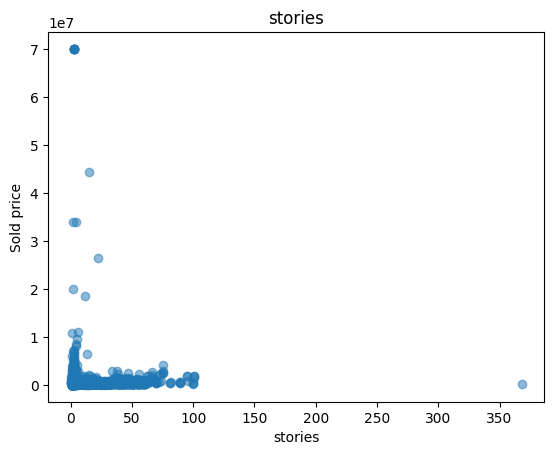

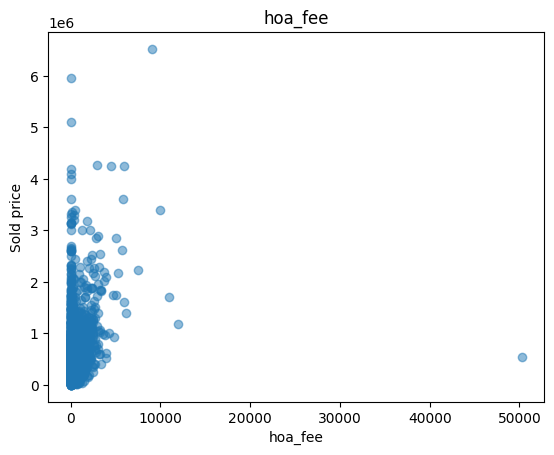

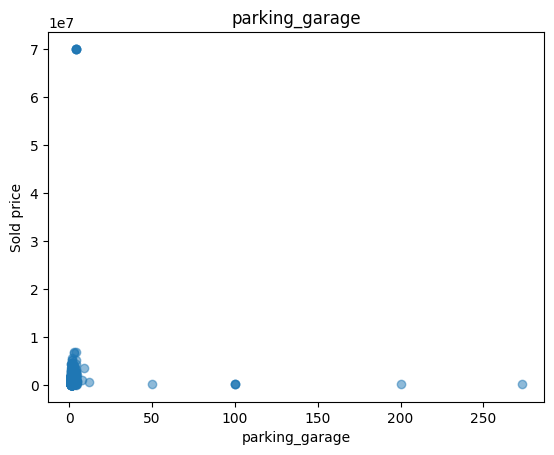

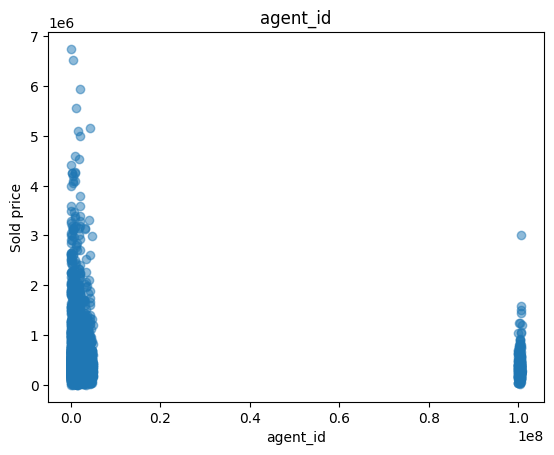

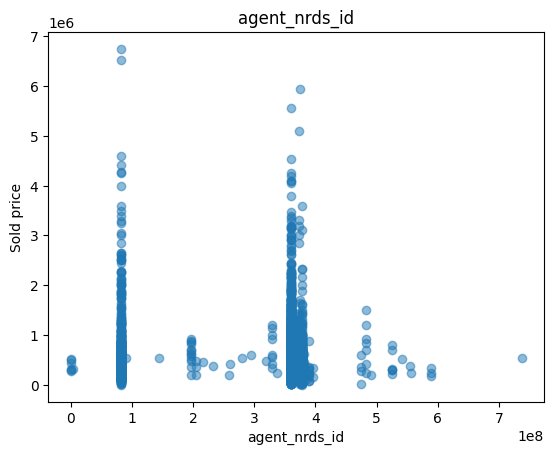

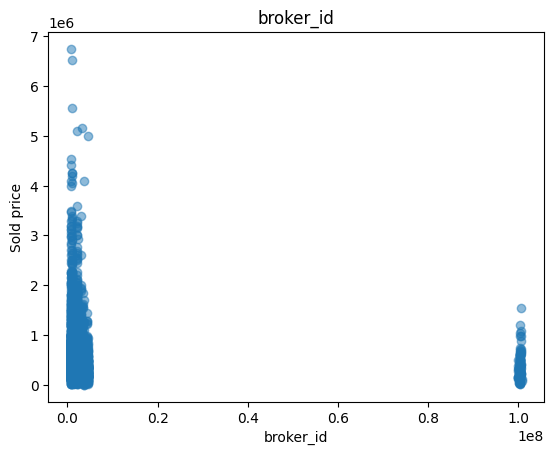

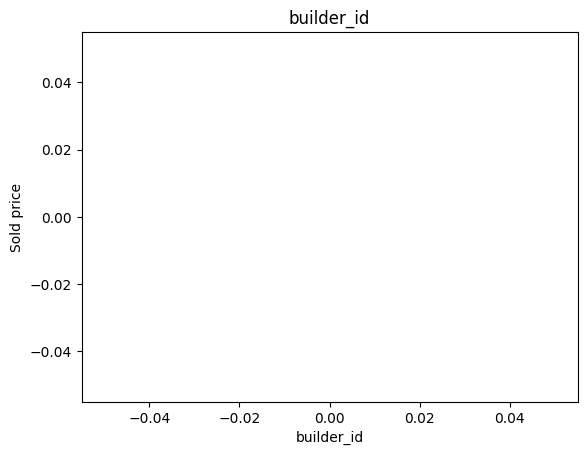

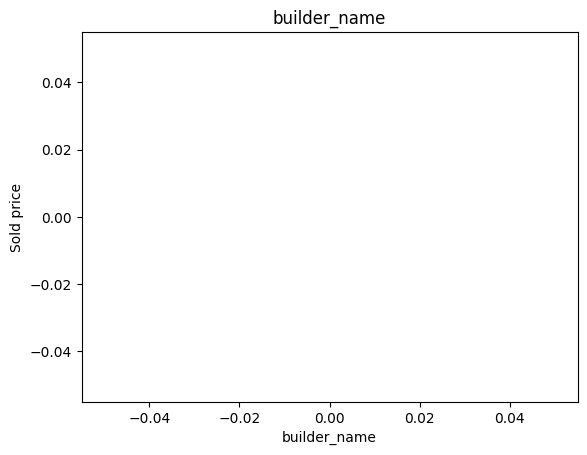

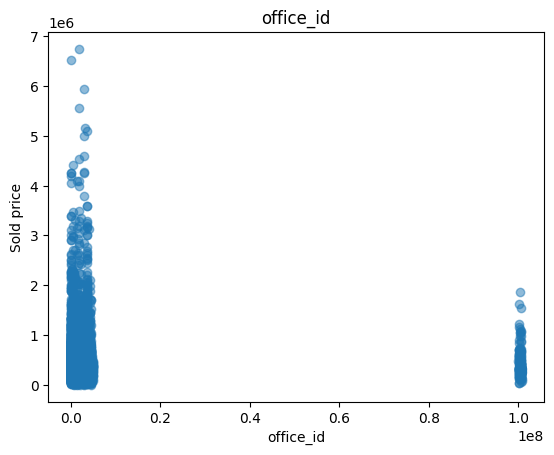

'\n    Insights:\n        Some graphs have little to no data, such as builder_id, and these can be eliminated.\n        There seems to be a relationship between house amenities, such as beds, baths, and \n        sqft, and tax; as these increase, so does the selling price. I will try to keep these attributes.\n\n    Bias:\n        I have my own views on how a house should be evaluated based off of certain features like\n        beds and bathrooms, so I may eliminate other possibly important features that I evaluate as\n        nonessential.\n'

In [233]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, r2_score
import matplotlib.pyplot as plt
import numpy as np


df = pd.read_csv('listing.csv')

df.columns = ['property_url','property_id', 'listing_id','permalink', 'mls',
             'mls_id', 'status','mls_status','text','style','formatted_address',
             'full_street_line','street','unit','city','state','zip_code','beds',
             'full_baths','half_baths','sqft','year_built','days_on_mls','list_price',
             'list_price_min','list_price_max','list_date','pending_data','sold_price',
              'last_sold_date','last_sold_price','assessed_value','estimated_value',
              'tax','tax_history','new_construction','lot_sqft','price_per_sqft',
              'latitude','longitude','neighborhoods','county','fips_code','stories',
              'hoa_fee','parking_garage','agent_id','agent_name','agent_email',
              'agent_phones','agent_mls_set','agent_nrds_id','broker_id','broker_name',
              'builder_id','builder_name','office_id','office_mls_set','office_name',
              'office_email', 'office_phones','nearby_schools','primary_photo','alt_photos']


# Create scatter plot showing the relationship between the sold price and each of the features
# in the data set.
for i in df.columns[1:]:
    X = df[i]
    price = df["sold_price"]
    if pd.api.types.is_numeric_dtype(X):
        plt.scatter(X,price,alpha=0.5)
        plt.xlabel(i)
        plt.ylabel("Sold price")
        plt.title(i)
        plt.show()

"""
    Insights:
        Some graphs have little to no data, such as builder_id, and these can be eliminated.
        There seems to be a relationship between house amenities, such as beds, baths, and 
        sqft, and tax; as these increase, so does the selling price. I will try to keep these attributes.

    Bias:
        I have my own views on how a house should be evaluated based off of certain features like
        beds and bathrooms, so I may eliminate other possibly important features that I evaluate as
        nonessential.
"""

# 4.Prepare the Data


Apply any data transformations and explain what and why


In [234]:
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler


""" Why:
        I am dropping these columns because they contain nonessential/redundant features.
        For instance, it is redundant to include the city and property_url as they are
        either accounted for or do not effect selling price whatsoever. 
        
        I have kept beds, full_baths, half_baths, sqft, year_built, tax, sold_price, hoa_fee, stories, garage
        because these are viewed as crucial features when determining the value of a house.

    Bias:
        By dropping so many columns, I may be removing data that can effect selling price. Moreover,
        by removing all columns with NaN values, I could be getting rid of more valid data. Also, the features
        I chose can be personally subjective, as these are the main factors I and my family have evaluated
        in our own recent purchasing of a house.
"""
# Keep beds, tax, full_baths, half_baths, sqft, year_built, sold_price, hoa_fee, stories, garage
df = df.drop(columns=['property_url','property_id', 'listing_id','permalink', 'mls',
             'mls_id', 'status','mls_status','text','style','formatted_address',
             'full_street_line','street','unit','city','state','days_on_mls','list_price',
             'list_price_min','list_price_max','list_date','pending_data',
              'last_sold_date','last_sold_price','assessed_value','estimated_value','tax','tax_history','new_construction','lot_sqft','price_per_sqft',
              'latitude','longitude','neighborhoods','county','fips_code','agent_id','agent_name','agent_email',
              'agent_phones','agent_mls_set','agent_nrds_id','broker_id','broker_name',
              'builder_id','builder_name','office_id','office_mls_set','office_name',
              'office_email','office_phones','nearby_schools','primary_photo','alt_photos'])

scaler = StandardScaler()
scaler.fit(df)

df['half_baths']=df['half_baths'].fillna(0)
df['beds']=df['beds'].fillna(0)
df['full_baths']=df['full_baths'].fillna(0)
df['parking_garage']=df['parking_garage'].fillna(0)
# Many NaN values in the data set; after experimentation, KNN imputer has worked the best in filling in this information
#df = pd.DataFrame(KNNImputer(n_neighbors=5).fit_transform(df),columns=df.columns)
df=df.dropna()
print(df)




      zip_code  beds  full_baths  half_baths    sqft  year_built  sold_price  \
206      60619   2.0         1.0         0.0  1000.0      1946.0      155000   
213      60640   3.0         2.0         0.0  1560.0      2006.0      580000   
215      60629   2.0         1.0         0.0   900.0      1969.0      163000   
218      60625   3.0         2.0         0.0  1372.0      1924.0      312500   
227      60654   2.0         2.0         0.0  1320.0      2001.0      470000   
...        ...   ...         ...         ...     ...         ...         ...   
9779     60625   3.0         2.0         0.0  1770.0      2017.0      850000   
9780     60640   1.0         1.0         0.0   760.0      1985.0      195000   
9790     60630   2.0         2.0         0.0  1700.0      1954.0      440000   
9791     60608   2.0         2.0         1.0  1600.0      2003.0      485000   
9792     60637   1.0         1.0         0.0   830.0      1940.0       24500   

      stories  hoa_fee  parking_garage 

# 5. Model the data
Using selected ML models, experment with your choices and describe your findings. Finish by selecting a Model to continue with


In [241]:
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor,
from sklearn.metrics import mean_absolute_percentage_error# for classification
import random
import pickle


target = 'sold_price'
features = df.columns[df.columns!=target]
print(features)
X = df[features].values
y = df[target].values

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.55,random_state=123)
print(X_train.shape,X_test.shape)

model = RandomForestRegressor(
        n_estimators = 1000,
        random_state=123,
        min_samples_leaf=1,
        n_jobs=-1)
model.fit(X_train,y_train)

"""
# 86% training accuracy, 70% testing accuracy
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

print("Train:", 1-(mean_absolute_percentage_error(y_train,y_train_pred)))
print("Test:", 1-(mean_absolute_percentage_error(y_test,y_test_pred)))
"""

pickle.dump(model, open('project2_model.pkl', 'wb'))


Index(['zip_code', 'beds', 'full_baths', 'half_baths', 'sqft', 'year_built',
       'stories', 'hoa_fee', 'parking_garage'],
      dtype='object')
(885, 9) (1082, 9)


# 6. Fine Tune the Model

With the select model descibe the steps taken to acheve the best rusults possiable 


In [ ]:
"""
    I started off with a Random Forest Regressor. However, when I would do the mean absolute percentage error, I could not get higher than a 33%
    accuracy on testing data and about 50% on training data. I figured something was very wrong with my dataset and how I am handling NaN values.
    At the beginning, I just dropped all NaN values, but once I saw how low the scores were, I decided to print my results and I only had about 100
    remaining. That is because there are many, many empty entires in the data set. Instead, I used a KNN imputer. While this improved the accuracy,
    it was still very poor. I tried to gather even more data, using a dataset with 9000 entries from the past two years rather than a dataset with
    7000 entires from the past year. This decreased my score. I was looking at the values through the dataset after I used KNN imputer and
    saw glaring inaccuracies; for example, all entries with no half baths had a value of 1 instead of 0. I set all baths, beds, and parking garages
    (as these values commonly have empty values representing 0) to 0 and used KNN imputer on the rest. This increased my accuracy to 50% on testing
    and about 80% in training. I decided to try dropping all remaining NaN columns, since the KNN imputer can create inaccurate data,
    and this imporved my accuracy to 60%. I decided to experiment with the hyperparameters to get this number even higher. The ML Summer book
    suggested a test size of 20% and training 80%, but I decided to use the standard conventional 30% test 70% train. This improved my accuracy by
    a few percentage points. The more I increased it, the higher the accuracy got, peaking at a 0.55 test split, resulting in 70% test accuracy and
    89% training accuracy.
"""

# 7. Present
In a customer faceing Document provide summery of finding and detail approach taken


In [ ]:
"""
    Problem: Given certain features of a home, predict how much it will cost in Chicago, Illinois.
    
    Summary of findings:
        One of the key findings of this project was that the year built of the house is the most crucial factor in determining its price,
        with about a 34% level of importance. Another key finding was that a very large dataset needed to be extracted from the internet;
        we upgraded from 4000 training datasets to about 10,000, ensuring accurate results stretching across a wide variety of homes.

    Detail approach:
        Using the HomeHarvest library, I gather about 10,000 examples of houses sold in Chicago to train our model. I removed all negligible data points, 
        such as the property url and text on the website, to focus on key features of homes. Using a Random Forest Regressor from the scikit-learn library,
        I was able to predict house price with a 70% accuracy, making the prediction well in the range of what it should be. I saved this trained model
        and made it such that the user can input features and receive a prediction for how much it would be sold for in Chicago, IL, making it a highly
        customizable user experience.
        
    

# 8. Launch the Model System
Define your production run code, This should be self susficent and require only your model pramaters 


In [252]:
with open('project2_model.pkl', 'rb') as f:
    loaded_model=pickle.load(f)

zip_code = int(input("Enter the zip code: "))
beds = int(input("Enter the number of beds: "))
full_baths = int(input("Enter the number of full baths: "))
half_baths = int(input("Enter the number of half baths: "))
sqft = int(input("Enter the number of square feet: "))
year_built = int(input("Enter the year built: "))
stories = int(input("Enter the number of stories: "))
hoa_fee = int(input("Enter the HOA feeL "))
parking_garage = int(input("Enter the number of parking garages: "))

def inference(zip_code,beds,full_baths,half_baths,sqft,year_built,stories,hoa_fee,parking_garage):
    new_features = pd.DataFrame({'zip_code':zip_code,
                                 'beds':[beds],
                                 'full_baths':[full_baths],
                                 'half_baths':[half_baths],
                                 'sqft':[sqft],
                                 'year_built':[year_built],
                                 'stories':[stories],
                                 'hoa_fee':[hoa_fee],
                                 'parking_garage':[parking_garage]
                                })

    prediction = loaded_model.predict(new_features.values)
    print("Predicted house price in Chicago, IL: ",prediction)

inference(zip_code,beds,full_baths,half_baths,sqft,year_built,stories,hoa_fee,parking_garage)
#Ta da!

Enter the zip code:  60007
Enter the number of beds:  2
Enter the number of full baths:  1
Enter the number of half baths:  0
Enter the number of square feet:  1000
Enter the year built:  1995
Enter the number of stories:  1
Enter the HOA feeL  100
Enter the number of parking garages:  0


Predicted house price in Chicago, IL:  [319729.656]
